# Discrete OU/AR(1) on BTC futures and perp

## Import Libraries

In [1]:
import sys

print(sys.executable)

/Users/emmanuelarowolo/btc_spot_perp_meanreversion-1/venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
#pulling in data
df = pd.read_csv(
    "/Users/emmanuelarowolo/btc_spot_perp_meanreversion-1/data/processed/mergedbtc_and_fundingrate.csv"
)

df.head()

,timestamp,spot_price,future_price,funding_rate
0,2023-05-06,28848.20,28837.8,NaN
1,2023-05-07,28430.10,28419.4,0.000144
2,2023-05-08,27668.79,27659.8,0.000050
3,2023-05-09,27628.27,27610.2,0.000123
4,2023-05-10,27598.75,27582.9,0.000123


In [4]:
#convert timestamp back to datetime
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

In [5]:
#set timestamp as index
df.set_index(
    "timestamp",
    inplace=True
)

df.head()

,spot_price,future_price,funding_rate
timestamp,,,
2023-05-06,28848.20,28837.8,NaN
2023-05-07,28430.10,28419.4,0.000144
2023-05-08,27668.79,27659.8,0.000050
2023-05-09,27628.27,27610.2,0.000123
2023-05-10,27598.75,27582.9,0.000123


## Feature Building

In [6]:
#creating spread percentage as basis
df["basis"] = (
    (df["future_price"] - df["spot_price"])
    / df["spot_price"]
)

#creating spread
df["spread"] = (
    df["future_price"] - df["spot_price"]
)

df.head()

,spot_price,future_price,funding_rate,basis,spread
timestamp,,,,,
2023-05-06,28848.20,28837.8,NaN,-0.000361,-10.40
2023-05-07,28430.10,28419.4,0.000144,-0.000376,-10.70
2023-05-08,27668.79,27659.8,0.000050,-0.000325,-8.99
2023-05-09,27628.27,27610.2,0.000123,-0.000654,-18.07
2023-05-10,27598.75,27582.9,0.000123,-0.000574,-15.85


### Plotting Basis

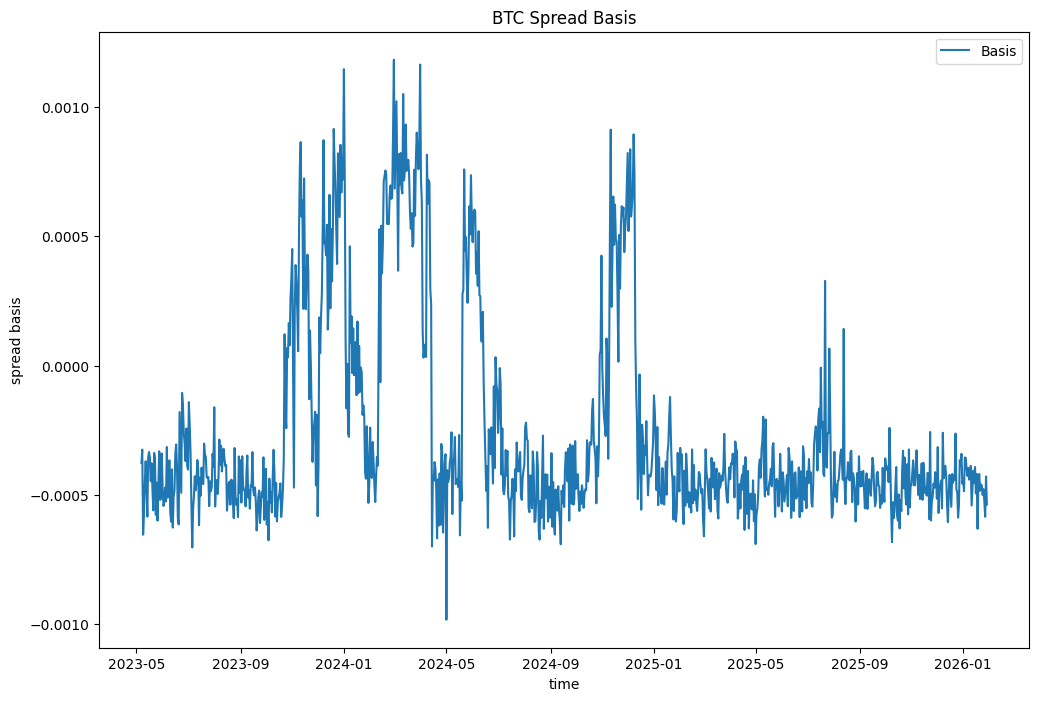

In [18]:
plt.figure(figsize=(12,8))

plt.plot(df.index, df["basis"], label="Basis")

plt.title("BTC Spread Basis")
plt.xlabel("time")
plt.ylabel("spread basis")

plt.legend()
plt.show()

In [8]:
#creating lagged basis
df["basis_lag"] = df["basis"].shift(1)

df = df.dropna()

## Fitting AR(1)

In [9]:
#define feature matrix
x = df[["basis_lag"]]
y = df["basis"]

#regression
model = LinearRegression()

#fit AR(1)
model.fit(x,y)

#extract parameters
a = model.intercept_
b = model.coef_[0]

print(f"intercept: {a}")
print(f"AR coefficient: {b}")

intercept: -2.5593869497887018e-05
AR coefficient: 0.8981800217172675


#### Findings
|b| < 1
  
So, it is mean reverting but just slowly  
  
The basis has memory, and today's deviation strongly influences tomorrow

## Characterisation of the OU process

### Calibrate OU Equilibrium

In [10]:
mu = (
    a /
    (1-b)
)

print(f"equilibrium basis: {mu}")

equilibrium basis: -0.00025136392611299006


Long run equilibrium mean is slightly negative
Futures on average are slightly underpriced vs spot

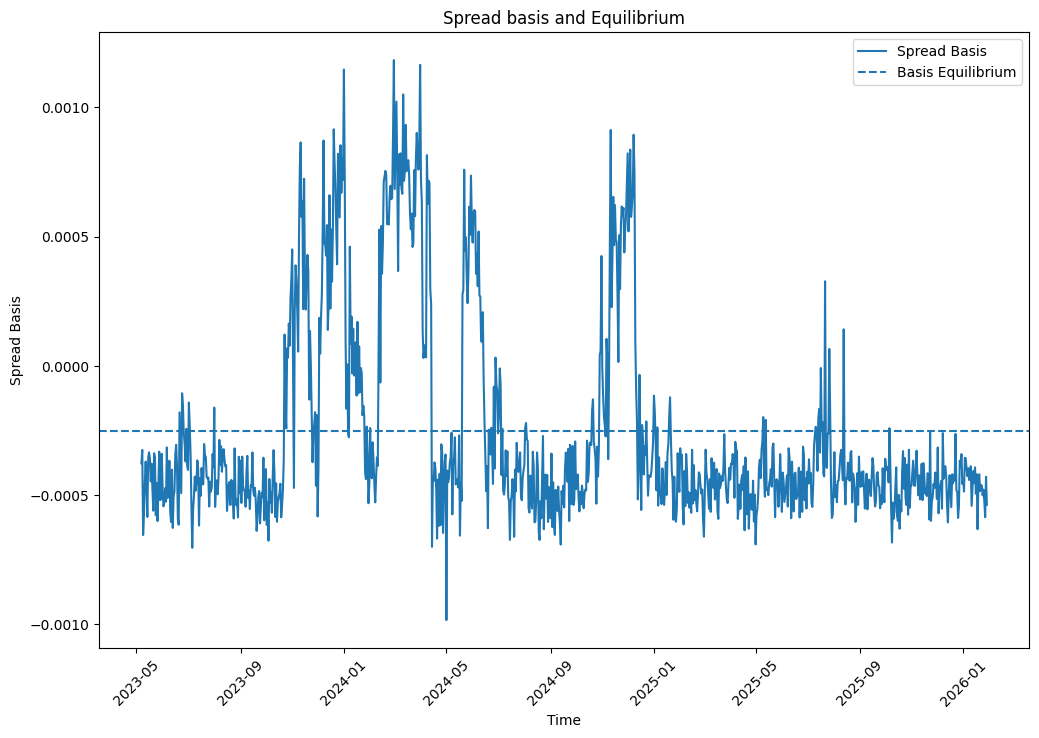

In [17]:
plt.figure(figsize=(12,8))
plt.plot(df.index, df["basis"], label="Spread Basis")
plt.axhline(
    y=mu,
    linestyle='--',
    label="Basis Equilibrium"
)

plt.title("Spread basis and Equilibrium")
plt.xlabel("Time")
plt.ylabel("Spread Basis")
plt.xticks(rotation=45)

plt.legend()
plt.show()

### Half life

In [19]:
half_life = -np.log(2) / np.log(b)
print(f"half life: {half_life} days")

half life: 6.45480022600874 days


## Feature generation

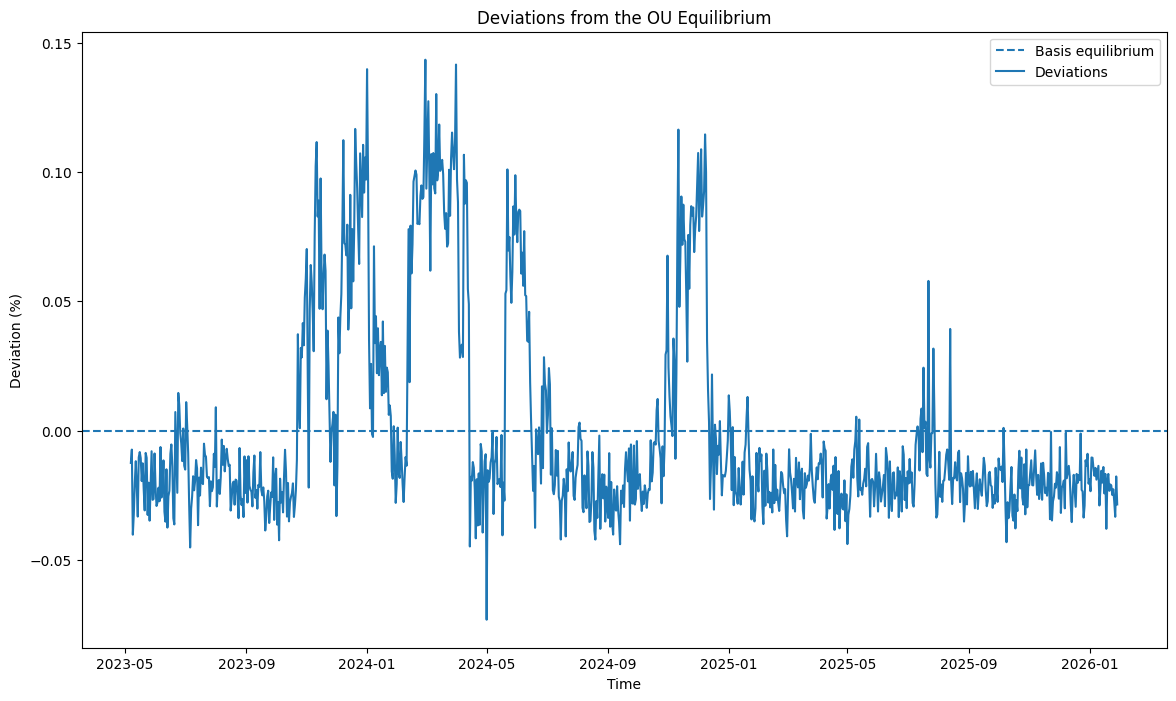

In [23]:
#plotting deviation from the equilibrium

#deviation = basis - equilibrium
df["deviations"] = df["basis"] - mu

#plot
plt.figure(figsize=(14,8))
plt.axhline(y=mu, linestyle="--", label="Basis equilibrium")
plt.plot(df.index, df["deviations"]*100, label="Deviations")
#plt.plot(df.index, df["basis"]*100, color="orange", label="Basis")

plt.title("Deviations from the OU Equilibrium")
plt.xlabel("Time")
plt.ylabel("Deviation (%)")

plt.legend()
plt.show()

In [30]:
#deviations standardisation

df["ou_forecast"]= ( a + b*df["basis_lag"])

#randomness not explained by the mean
df["residuals"] = (df["basis"] - df["ou_forecast"])

#Sigma
sigma = df["residuals"].std()
print(sigma)

0.00017596090570726132


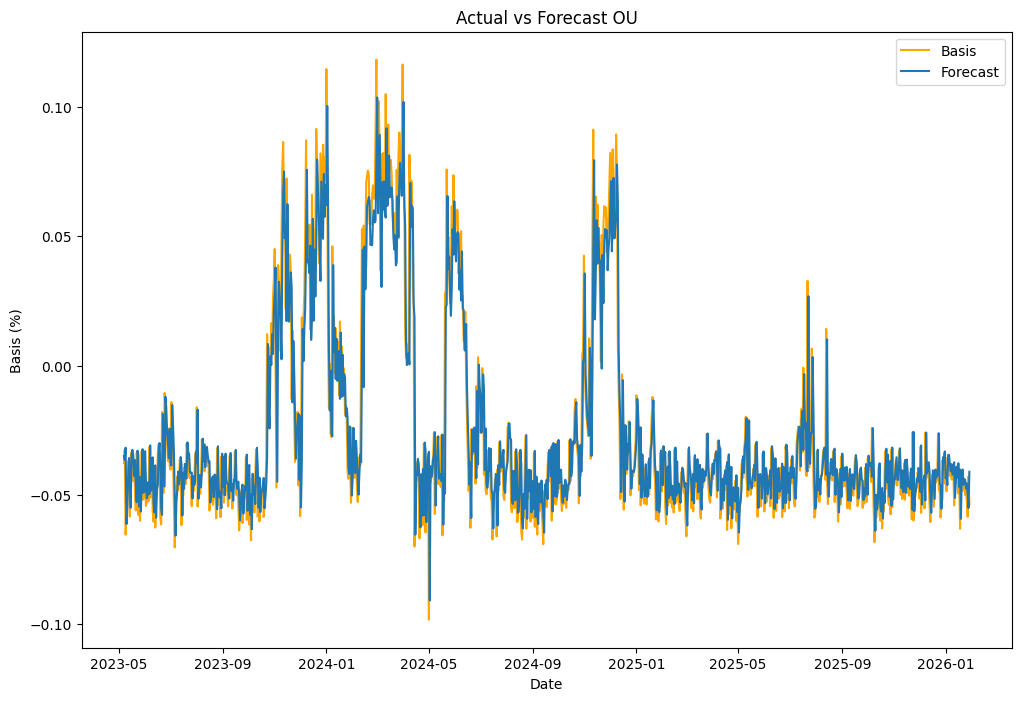

In [34]:
#deterministic OU forecast path
plt.figure(figsize=(12,8))
plt.plot(df.index, df["basis"]*100, label="Basis", color="orange")
plt.plot(df.index, df["ou_forecast"]*100, label="Forecast")
plt.title("Actual vs Forecast OU")
plt.xlabel("Date")
plt.ylabel("Basis (%)")
plt.legend()
plt.show()

In [32]:
#OU zscore

df["ou_zscore"] = df["deviations"]/sigma

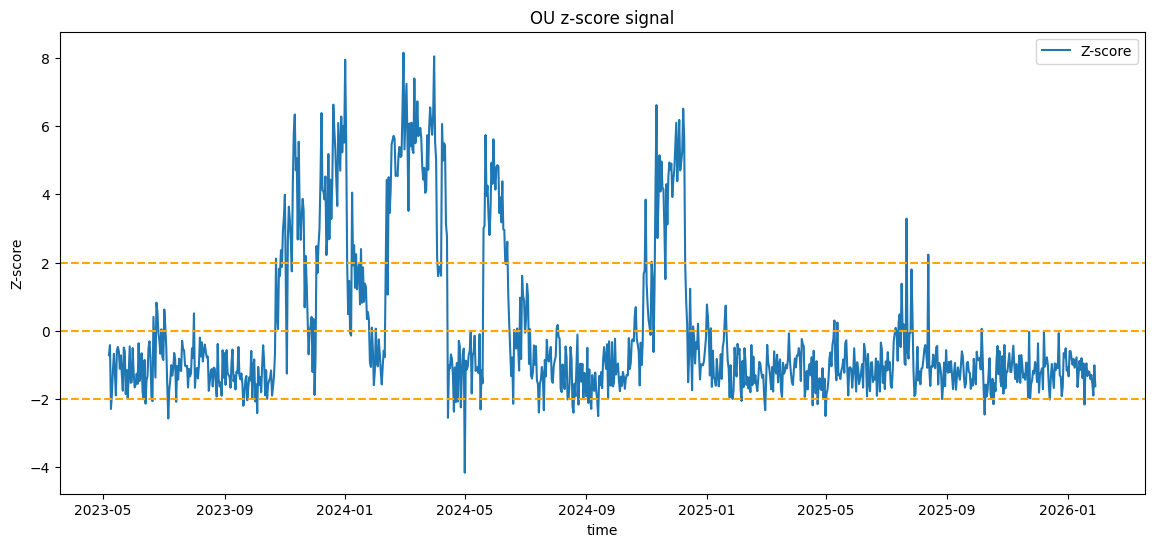

In [33]:
#visualising OU_zscore signal
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df["ou_zscore"],
    label="Z-score"
)

plt.axhline(2, linestyle="--", color="orange")
plt.axhline(0, linestyle="--", color="orange")
plt.axhline(-2, linestyle="--", color="orange")

plt.title("OU z-score signal")
plt.xlabel("time")
plt.ylabel("Z-score")
plt.legend()
plt.show()

#### Findings

Shorts achieve normalisation way faster than longs  
  
This is because of funding costs, leverage unwinds, liquidation occurs so reversion is more violant and reliable.

I would need to split the long and short into seperate processes. Seperate half lives because and expand into a regime-dependant OU model.

But before all that, let's add noise!!!

## Trading Rules, Backtest and Performance Analysis

### Trading rules

In [63]:
short_signal = (df["ou_zscore"]>2) & (df["ou_zscore"].shift(1) <= 2) #& (df["funding_rate"] > 0)

long_signal = (df["ou_zscore"]<-2) & (df["ou_zscore"].shift(1)>=-2) #& (df["funding_rate"]<0)

In [64]:
short_events = short_signal.sum()

long_events = long_signal.sum()

print(f"Number of long signals: {long_events}")
print(f"Number of short signals: {short_events}")

Number of long signals: 35
Number of short signals: 23


In [38]:
df.head()

,spot_price,future_price,funding_rate,basis,spread,basis_lag,deviations,ou_forecast,residuals,ou_zscore
timestamp,,,,,,,,,,
2023-05-07,28430.10,28419.4,0.000144,-0.000376,-10.70,-0.000361,-0.000125,-0.000349,-0.000027,-0.710372
2023-05-08,27668.79,27659.8,0.000050,-0.000325,-8.99,-0.000376,-0.000074,-0.000364,0.000039,-0.417996
2023-05-09,27628.27,27610.2,0.000123,-0.000654,-18.07,-0.000325,-0.000403,-0.000317,-0.000337,-2.288442
2023-05-10,27598.75,27582.9,0.000123,-0.000574,-15.85,-0.000654,-0.000323,-0.000613,0.000039,-1.835280
2023-05-11,26968.62,26956.4,0.000137,-0.000453,-12.22,-0.000574,-0.000202,-0.000541,0.000088,-1.146592


In [65]:
#trading logic and position column
df["positions"] = 0
current_position = 0
positions = []

for i in range(len(df)):
    z = df["ou_zscore"].iloc[i]

    #entry
    if current_position == 0:
        if short_signal.iloc[i]:
            current_position = -1
        elif long_signal.iloc[i]:
            current_position=1
    
    #exit
    elif current_position == -1 and z<=0:
        current_position = 0
    elif current_position == 1 and z>=0:
        current_position = 0
    
    positions.append(current_position)

df["positions"] = positions

df
    

,spot_price,future_price,funding_rate,basis,spread,basis_lag,deviations,ou_forecast,residuals,ou_zscore,positions,basis_returns,strategy_returns,funding_pnl,total_returns,equity
timestamp,,,,,,,,,,,,,,,,
2023-05-07,28430.10,28419.4,0.000144,-0.000376,-10.70,-0.000361,-0.000125,-0.000349,-0.000027,-0.710372,0,NaN,NaN,0.000000,NaN,NaN
2023-05-08,27668.79,27659.8,0.000050,-0.000325,-8.99,-0.000376,-0.000074,-0.000364,0.000039,-0.417996,0,0.000051,0.000000,0.000000,0.000000,10000.000000
2023-05-09,27628.27,27610.2,0.000123,-0.000654,-18.07,-0.000325,-0.000403,-0.000317,-0.000337,-2.288442,1,-0.000329,-0.000000,0.000000,-0.000000,10000.000000
2023-05-10,27598.75,27582.9,0.000123,-0.000574,-15.85,-0.000654,-0.000323,-0.000613,0.000039,-1.835280,1,0.000080,0.000000,0.000000,0.000000,10000.000000
2023-05-11,26968.62,26956.4,0.000137,-0.000453,-12.22,-0.000574,-0.000202,-0.000541,0.000088,-1.146592,1,0.000121,0.000000,0.000000,0.000000,10000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-25,86670.36,86628.9,0.000143,-0.000478,-41.46,-0.000500,-0.000227,-0.000475,-0.000003,-1.290061,1,0.000022,0.000022,0.000143,0.000022,10097.301027
2026-01-26,88347.08,88300.6,0.000125,-0.000526,-46.48,-0.000478,-0.000275,-0.000455,-0.000071,-1.561386,1,-0.000048,-0.000048,0.000125,-0.000048,10096.818956
2026-01-27,89250.00,89197.8,0.000178,-0.000585,-52.20,-0.000526,-0.000334,-0.000498,-0.000087,-1.895364,1,-0.000059,-0.000059,0.000178,-0.000059,10096.225595


In [ ]:
df.to_csv("positions_ouzscore"""_funding""".csv")

### Adding equity and visualistion

In [67]:
df["basis_returns"] = (
    df["basis"].diff()
)

df["strategy_returns"] = (
    df["positions"].shift(1) * 
    df["basis_returns"]
)

df["funding_pnl"] = (
    df["positions"] *
    df["funding_rate"]
)

df["total_returns"] = (
    (df["strategy_returns"]) #+ 
    #df["funding_pnl"]
)

initial_cap = 10000

df["equity"] = (
    initial_cap * 
    (1+df["total_returns"]).cumprod() #returns compound multipucatively not additionally
)

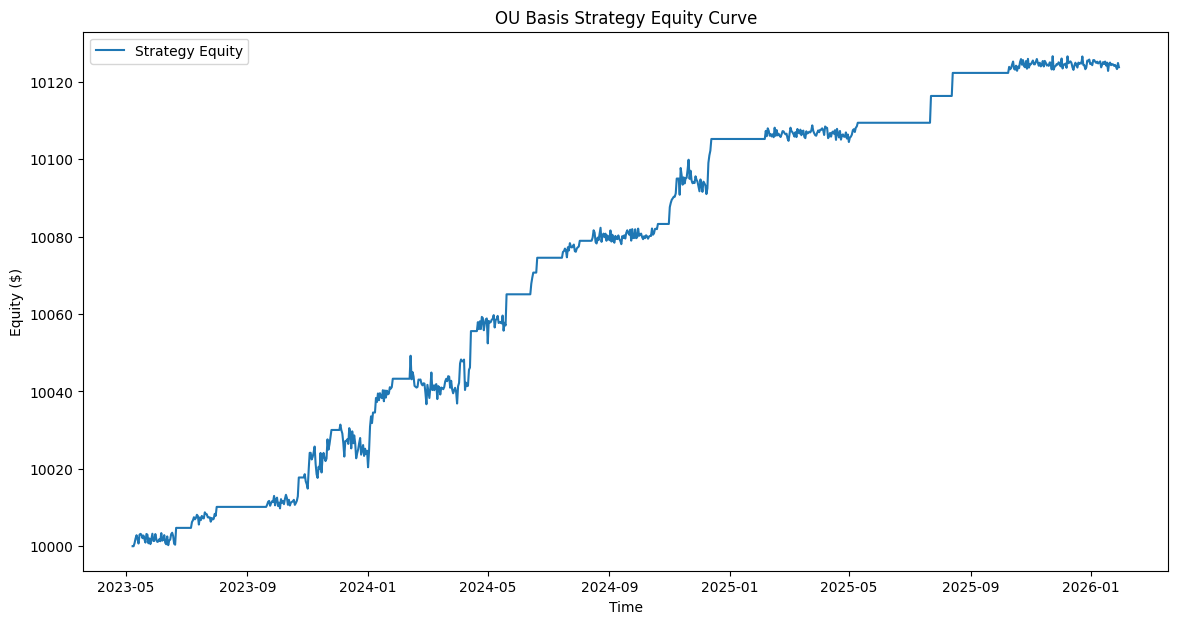

In [68]:
plt.figure(figsize=(14,7))

plt.plot(df.index, df["equity"], label="Strategy Equity")
plt.title("OU Basis Strategy Equity Curve")
plt.xlabel("Time")
plt.ylabel("Equity ($)")
plt.legend()
plt.show()

Directionally correct but economically horrible.  
  
Have to delve into why

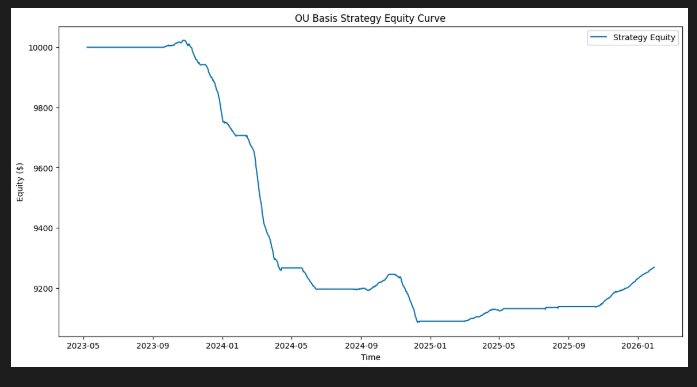

With funding. Strongly negative

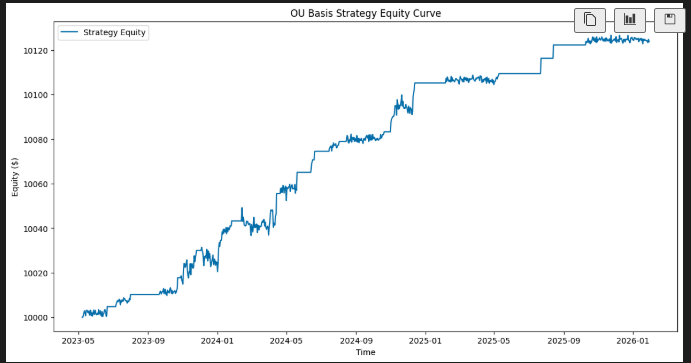

Without funding. Slightly profitable. low vol. slow compounding.  
  
Statistically valid convergence does not survive financing costs without even including transactions, slippage etc.


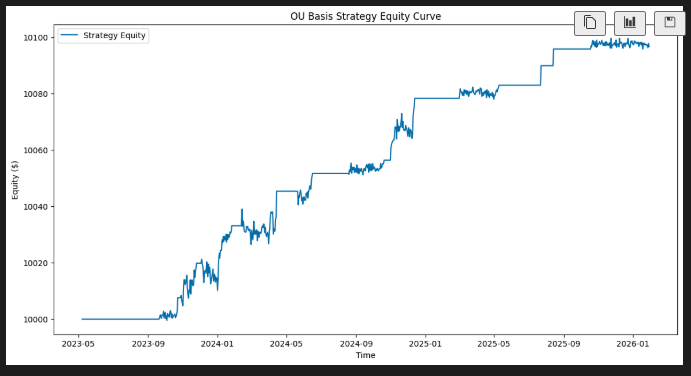

In [62]:
df

,spot_price,future_price,funding_rate,basis,spread,basis_lag,deviations,ou_forecast,residuals,ou_zscore,positions,basis_returns,strategy_returns,funding_pnl,total_returns,equity
timestamp,,,,,,,,,,,,,,,,
2023-05-07,28430.10,28419.4,0.000144,-0.000376,-10.70,-0.000361,-0.000125,-0.000349,-0.000027,-0.710372,0,NaN,NaN,0.000000,NaN,NaN
2023-05-08,27668.79,27659.8,0.000050,-0.000325,-8.99,-0.000376,-0.000074,-0.000364,0.000039,-0.417996,0,0.000051,0.000000,0.000000,0.000000,10000.000000
2023-05-09,27628.27,27610.2,0.000123,-0.000654,-18.07,-0.000325,-0.000403,-0.000317,-0.000337,-2.288442,0,-0.000329,-0.000000,0.000000,-0.000000,10000.000000
2023-05-10,27598.75,27582.9,0.000123,-0.000574,-15.85,-0.000654,-0.000323,-0.000613,0.000039,-1.835280,0,0.000080,0.000000,0.000000,0.000000,10000.000000
2023-05-11,26968.62,26956.4,0.000137,-0.000453,-12.22,-0.000574,-0.000202,-0.000541,0.000088,-1.146592,0,0.000121,0.000000,0.000000,0.000000,10000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-25,86670.36,86628.9,0.000143,-0.000478,-41.46,-0.000500,-0.000227,-0.000475,-0.000003,-1.290061,1,0.000022,0.000022,0.000143,0.000022,10097.301027
2026-01-26,88347.08,88300.6,0.000125,-0.000526,-46.48,-0.000478,-0.000275,-0.000455,-0.000071,-1.561386,1,-0.000048,-0.000048,0.000125,-0.000048,10096.818956
2026-01-27,89250.00,89197.8,0.000178,-0.000585,-52.20,-0.000526,-0.000334,-0.000498,-0.000087,-1.895364,1,-0.000059,-0.000059,0.000178,-0.000059,10096.225595


### Performance analysis

In [70]:
#sharpe ratio
returns = df["strategy_returns"].dropna()

sharpe = returns.mean() / returns.std()

sharpe = sharpe * np.sqrt(365)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 1.601888259190257


Max drawdown: -0.0012467755378304229


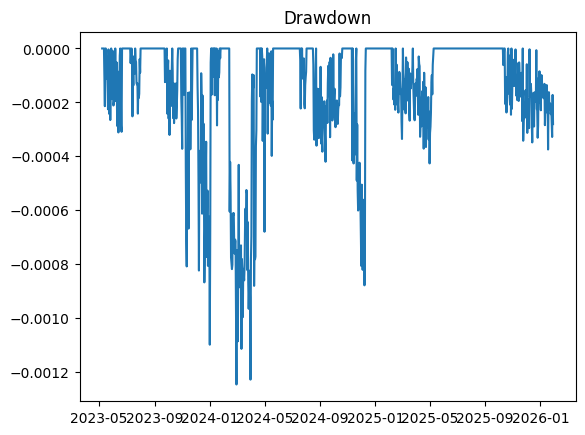

In [71]:
#max drawdown
equity = df["equity"]

rolling_max = equity.cummax()

drawdown = (equity - rolling_max)/ rolling_max


max_drawdown = drawdown.min()

print("Max drawdown:", max_drawdown)

plt.plot(drawdown)
plt.title("Drawdown")
plt.show()

In [ ]:
df["final_pnl"] = df["equity"] - initial_cap

#win rate
win_rate = ( df["final_pnl"]> 0).mean()

print("Win rate:", win_rate)

#needs to be at trade level. Currently at path level so this code is wrong. Need a trade table

Win rate: 0.996996996996997


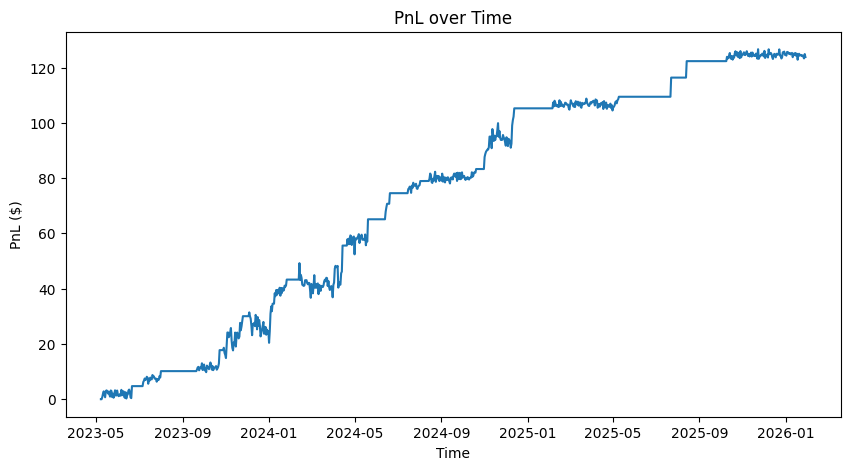

In [79]:
#pnl
df["final_pnl"] = df["equity"] - initial_cap

plt.figure(figsize=(10,5))
plt.plot(df.index, df["final_pnl"], label="pnl")
plt.title("PnL over Time")
plt.xlabel("Time")
plt.ylabel("PnL ($)")
plt.show()